In [10]:
!pip install selenium

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
    --------------------------------------- 0.2/9.5 MB 5.3 MB/s eta 0:00:02
   -- ------------------------------------- 0.6/9.5 MB 7.2 MB/s eta 0:00:02
   ---- ----------------------------------- 1.0/9.5 MB 8.9 MB/s eta 0:00:01
   ------ --------------------------------- 1.6/9.5 MB 9.9 MB/s eta 0:00:01
   --------- ------------------------------ 2.4/9.5 MB 11.6 MB/s eta 0:00:01
   ------------- -------------------------- 3.1/9.5 MB 12.5 MB/s eta 0:00:01
   ----------------- ---------------------- 4.2/9.5 MB 14.2 MB/s eta 0:00:01
   --------------------- ------------------ 5.0/9.5 MB 15.3 MB/s eta 0:00:01
   ------------------------- -------------- 6.1/9.5 MB 16.2 MB/s eta 0:00:01
   ------------------------------ --------- 7.2/9.5 MB 17.1 MB/s eta 0:00:01
   --------------------------------- ------ 8.0/9.5 MB 17.1 MB/s eta 0:00:01
   -------------------------------------- - 9.1/9.5 MB 18.2 MB/s eta 0:00:01
   --------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
httpcore 1.0.2 requires h11<0.15,>=0.13, but you have h11 0.16.0 which is incompatible.
s3transfer 0.14.0 requires botocore<2.0a.0,>=1.37.4, but you have botocore 1.34.69 which is incompatible.
streamlit 1.32.0 requires protobuf<5,>=3.20, but you have protobuf 6.32.1 which is incompatible.


In [1]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from bs4 import BeautifulSoup
import pandas as pd
import time

URL = "https://worldpopulationreview.com/world-cities"

def scrape_most_populated_cities():
    # Set up a "headless" browser (runs in the background without opening a window)
    options = Options()
    options.add_argument("--headless=new")
    driver = webdriver.Chrome(options=options)
    
    # Fetch the webpage and wait a few seconds for JavaScript to render the table
    driver.get(URL)
    time.sleep(3)  
    
    # Pass the fully rendered HTML to BeautifulSoup
    soup = BeautifulSoup(driver.page_source, "html.parser")
    driver.quit()  # Close the background browser

    # Find the table containing city population data
    table = soup.find("table") 
    
    # Safety check to prevent future crashes
    if table is None:
        print("Error: Table not found. The website structure may have changed.")
        return None

    rows = table.find_all("tr")[1:]  # Skip the header row

    # Extract data using your original logic
    city_list = []
    for row in rows:
        cols = row.find_all("td")
        if len(cols) >= 6:  
            city = cols[2].get_text(strip=True)  
            country = cols[3].get_text(strip=True)  
            population = cols[4].get_text(strip=True).replace(",", "")  
            city_list.append([city, country, population])

    # Create a DataFrame
    df_cities = pd.DataFrame(city_list, columns=["City", "Country", "Population"])

    # Save to CSV
    df_cities.to_csv("most_populated_cities.csv", index=False)
    print("Saved data to most_populated_cities.csv")

    return df_cities



In [2]:
# Run the function
df_cities = scrape_most_populated_cities()

df_cities.head(10)

Saved data to most_populated_cities.csv


,City,Country,Population
0,Tokyo,Japan,36953600
1,Delhi,India,35518400
2,Shanghai,China,31049800
3,Dhaka,Bangladesh,25359100
4,Cairo,Egypt,23534600
5,Sao Paulo,Brazil,23168700
6,Mexico City,Mexico,23016800
7,Beijing,China,22983400
8,Mumbai,India,22539300
9,Osaka,Japan,18873900


In [3]:
df_top_10_cities = df_cities.head(10)

In [5]:
import requests
city_list = []
lat_list = []
lon_list = []
for city in df_top_10_cities["City"]:
    print(city)
    city_list.append(city)
    geo_url = f"https://geocoding-api.open-meteo.com/v1/search?name={city}&count=1&language=en&format=json"
    geo_response = requests.get(geo_url).json()
    print(geo_response)
    lat = geo_response["results"][0]["latitude"]
    lon = geo_response["results"][0]["longitude"]
    print(lat, lon)

    lat_list.append(lat)
    lon_list.append(lon)

print(city_list, lat_list, lon_list)


Tokyo
{'results': [{'id': 1850147, 'name': 'Tokyo', 'latitude': 35.6895, 'longitude': 139.69171, 'elevation': 44.0, 'feature_code': 'PPLC', 'country_code': 'JP', 'admin1_id': 1850144, 'timezone': 'Asia/Tokyo', 'population': 9733276, 'country_id': 1861060, 'country': 'Japan', 'admin1': 'Tokyo'}], 'generationtime_ms': 0.9537935}
35.6895 139.69171
Delhi
{'results': [{'id': 1273294, 'name': 'Delhi', 'latitude': 28.65195, 'longitude': 77.23149, 'elevation': 227.0, 'feature_code': 'PPLA', 'country_code': 'IN', 'admin1_id': 1273293, 'timezone': 'Asia/Kolkata', 'population': 11034555, 'country_id': 1269750, 'country': 'India', 'admin1': 'Delhi'}], 'generationtime_ms': 1.3363361}
28.65195 77.23149
Shanghai
{'results': [{'id': 1796236, 'name': 'Shanghai', 'latitude': 31.22222, 'longitude': 121.45806, 'elevation': 12.0, 'feature_code': 'PPLA', 'country_code': 'CN', 'admin1_id': 1796231, 'admin2_id': 12324204, 'timezone': 'Asia/Shanghai', 'population': 24874500, 'country_id': 1814991, 'country': '

In [6]:
geo_response["results"][0]["latitude"]

34.69379

In [7]:
df_Coordinate = pd.DataFrame({"City": city_list, "Latitude": lat_list, "Longitude": lon_list})
df_Coordinate

,City,Latitude,Longitude
0,Tokyo,35.68950,139.69171
1,Delhi,28.65195,77.23149
2,Shanghai,31.22222,121.45806
3,Dhaka,23.71040,90.40744
4,Cairo,30.06263,31.24967
5,Sao Paulo,-23.54750,-46.63611
6,Mexico City,19.42847,-99.12766
7,Beijing,39.90750,116.39723
8,Mumbai,19.07283,72.88261
9,Osaka,34.69379,135.50107


In [ ]:
! pip install openmeteo-requests
! pip install requests-cache retry-requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 2.9 MB/s eta 0:00:00


In [8]:
import openmeteo_requests
import numpy as np
import requests_cache
import pandas as pd
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

temp = []
wind_speed = []

for (latitude, longitude) in zip(df_Coordinate["Latitude"], df_Coordinate["Longitude"]):

  url = "https://api.open-meteo.com/v1/forecast"
  params = {
    "latitude": latitude,
    "longitude": longitude,
    "current": ["temperature_2m", "wind_speed_10m"],
  }
  responses = openmeteo.weather_api(url, params=params)
  response = responses[0]

  # Current values. The order of variables needs to be the same as requested.
  current = response.Current()

  current_temperature_2m = np.round(current.Variables(0).Value(),2)
  temp.append(current_temperature_2m)

  current_wind_speed_10m = current.Variables(1).Value()
  wind_speed.append(current_wind_speed_10m)

print(temp, wind_speed)

[5.91, 31.2, 12.9, 29.85, 12.18, 19.61, 16.1, 11.74, 30.68, 8.6] [6.877789497375488, 1.4399999380111694, 2.2768397331237793, 1.1384198665618896, 5.692099571228027, 5.483356475830078, 2.595996856689453, 4.349896430969238, 0.8049845099449158, 11.92898941040039]


In [9]:
df_weather = pd.DataFrame({"Latitude": lat_list, "Longitude": lon_list, "Temperature": temp, "Wind_Speed": wind_speed})
df_weather

,Latitude,Longitude,Temperature,Wind_Speed
0,35.68950,139.69171,5.91,6.877789
1,28.65195,77.23149,31.20,1.440000
2,31.22222,121.45806,12.90,2.276840
3,23.71040,90.40744,29.85,1.138420
4,30.06263,31.24967,12.18,5.692100
5,-23.54750,-46.63611,19.61,5.483356
6,19.42847,-99.12766,16.10,2.595997
7,39.90750,116.39723,11.74,4.349896
8,19.07283,72.88261,30.68,0.804985
9,34.69379,135.50107,8.60,11.928989


In [10]:
df_Coordinate

,City,Latitude,Longitude
0,Tokyo,35.68950,139.69171
1,Delhi,28.65195,77.23149
2,Shanghai,31.22222,121.45806
3,Dhaka,23.71040,90.40744
4,Cairo,30.06263,31.24967
5,Sao Paulo,-23.54750,-46.63611
6,Mexico City,19.42847,-99.12766
7,Beijing,39.90750,116.39723
8,Mumbai,19.07283,72.88261
9,Osaka,34.69379,135.50107


In [11]:
df_merged = pd.merge(df_Coordinate, df_weather, on=["Latitude", "Longitude"], how="inner")

In [12]:
df_merged

,City,Latitude,Longitude,Temperature,Wind_Speed
0,Tokyo,35.68950,139.69171,5.91,6.877789
1,Delhi,28.65195,77.23149,31.20,1.440000
2,Shanghai,31.22222,121.45806,12.90,2.276840
3,Dhaka,23.71040,90.40744,29.85,1.138420
4,Cairo,30.06263,31.24967,12.18,5.692100
5,Sao Paulo,-23.54750,-46.63611,19.61,5.483356
6,Mexico City,19.42847,-99.12766,16.10,2.595997
7,Beijing,39.90750,116.39723,11.74,4.349896
8,Mumbai,19.07283,72.88261,30.68,0.804985
9,Osaka,34.69379,135.50107,8.60,11.928989


In [13]:
df_weather = df_merged.copy()
df_weather

,City,Latitude,Longitude,Temperature,Wind_Speed
0,Tokyo,35.68950,139.69171,5.91,6.877789
1,Delhi,28.65195,77.23149,31.20,1.440000
2,Shanghai,31.22222,121.45806,12.90,2.276840
3,Dhaka,23.71040,90.40744,29.85,1.138420
4,Cairo,30.06263,31.24967,12.18,5.692100
5,Sao Paulo,-23.54750,-46.63611,19.61,5.483356
6,Mexico City,19.42847,-99.12766,16.10,2.595997
7,Beijing,39.90750,116.39723,11.74,4.349896
8,Mumbai,19.07283,72.88261,30.68,0.804985
9,Osaka,34.69379,135.50107,8.60,11.928989


In [14]:
# Rename specific columns
df_weather = df_weather.rename(columns={
    'Temperature': 'Temperature (°C)', 
    'Wind_Speed': 'Wind Speed (km/h)'
})

# Display the updated dataframe
df_weather

,City,Latitude,Longitude,Temperature (°C),Wind Speed (km/h)
0,Tokyo,35.68950,139.69171,5.91,6.877789
1,Delhi,28.65195,77.23149,31.20,1.440000
2,Shanghai,31.22222,121.45806,12.90,2.276840
3,Dhaka,23.71040,90.40744,29.85,1.138420
4,Cairo,30.06263,31.24967,12.18,5.692100
5,Sao Paulo,-23.54750,-46.63611,19.61,5.483356
6,Mexico City,19.42847,-99.12766,16.10,2.595997
7,Beijing,39.90750,116.39723,11.74,4.349896
8,Mumbai,19.07283,72.88261,30.68,0.804985
9,Osaka,34.69379,135.50107,8.60,11.928989


In [15]:
import sqlite3

# Load the scraped city data
# df_cities = pd.read_csv("most_populated_cities.csv")
# df_weather = pd.read_csv("weather_data.csv")

# Connect to SQLite database (or create if not exists)
conn = sqlite3.connect("city_weather.db")
cursor = conn.cursor() # A cursor is essentially your "messenger." It's the object you use to send SQL commands to the database


# Create the 'cities' table
cursor.execute('''
    CREATE TABLE IF NOT EXISTS cities (
        city TEXT PRIMARY KEY,
        country TEXT,
        population INTEGER
    )
''')

# Create the 'weather' table
cursor.execute('''
    CREATE TABLE IF NOT EXISTS weather (
        city TEXT PRIMARY KEY,
        country TEXT,
        temperature REAL,
        wind_speed REAL,
        FOREIGN KEY(city) REFERENCES cities(city)
    )
''')

# Insert city data
df_top_10_cities.to_sql("cities", conn, if_exists="append", index=False)

# Insert weather data
df_weather.to_sql("weather", conn, if_exists="append", index=False)

# Commit and close the connection
conn.commit() # This saves all the changes you made to the database file
conn.close() # This closes the connection to the database file, freeing up your computer's resources

print("Data successfully stored in city_weather.db")


Data successfully stored in city_weather.db


In [16]:
# Connect to SQLite database
conn = sqlite3.connect("city_weather.db")

# Load data into Pandas DataFrame
df_cities_db = pd.read_sql_query("SELECT * FROM cities", conn)
df_weather_db = pd.read_sql_query("SELECT * FROM weather", conn)

df_cities_db.head()




,City,Country,Population
0,Tokyo,Japan,36953600
1,Delhi,India,35518400
2,Shanghai,China,31049800
3,Dhaka,Bangladesh,25359100
4,Cairo,Egypt,23534600


In [18]:
df_cities_db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   City        30 non-null     object
 1   Country     30 non-null     object
 2   Population  30 non-null     object
dtypes: object(3)
memory usage: 852.0+ bytes


In [19]:
df_weather_db.head()

,City,Latitude,Longitude,Temperature (°C),Wind Speed (km/h)
0,Tokyo,35.68950,139.69171,5.91,6.877789
1,Delhi,28.65195,77.23149,31.20,1.440000
2,Shanghai,31.22222,121.45806,12.90,2.276840
3,Dhaka,23.71040,90.40744,29.85,1.138420
4,Cairo,30.06263,31.24967,12.18,5.692100


In [20]:
df_weather_db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               30 non-null     object 
 1   Latitude           30 non-null     float64
 2   Longitude          30 non-null     float64
 3   Temperature (°C)   30 non-null     float64
 4   Wind Speed (km/h)  30 non-null     float64
dtypes: float64(4), object(1)
memory usage: 1.3+ KB


In [21]:
# Close connection
conn.close()

# Merge both datasets
df = pd.merge(df_cities_db, df_weather_db, on=["City"], how="inner")

# Convert data types
df["Population"] = pd.to_numeric(df["Population"], errors="coerce")
df["Temperature (°C)"] = pd.to_numeric(df["Temperature (°C)"], errors="coerce")
df["Wind Speed (km/h)"] = pd.to_numeric(df["Wind Speed (km/h)"], errors="coerce")

In [22]:
df

,City,Country,Population,Latitude,Longitude,Temperature (°C),Wind Speed (km/h)
0,Tokyo,Japan,36953600,35.68950,139.69171,5.91,6.877789
1,Tokyo,Japan,36953600,35.68950,139.69171,5.91,6.877789
2,Tokyo,Japan,36953600,35.68950,139.69171,5.91,6.877789
3,Delhi,India,35518400,28.65195,77.23149,31.20,1.440000
4,Delhi,India,35518400,28.65195,77.23149,31.20,1.440000
...,...,...,...,...,...,...,...
85,Mumbai,India,22539300,19.07283,72.88261,30.68,0.804985
86,Mumbai,India,22539300,19.07283,72.88261,30.68,0.804985
87,Osaka,Japan,18873900,34.69379,135.50107,8.60,11.928989
88,Osaka,Japan,18873900,34.69379,135.50107,8.60,11.928989


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               90 non-null     object 
 1   Country            90 non-null     object 
 2   Population         90 non-null     int64  
 3   Latitude           90 non-null     float64
 4   Longitude          90 non-null     float64
 5   Temperature (°C)   90 non-null     float64
 6   Wind Speed (km/h)  90 non-null     float64
dtypes: float64(4), int64(1), object(2)
memory usage: 5.1+ KB


In [24]:
# Finding hottest and coldest city
hottest_city = df.loc[df["Temperature (°C)"].idxmax()]
coldest_city = df.loc[df["Temperature (°C)"].idxmin()]

print("Hottest City:")
print(hottest_city[["City", "Country", "Temperature (°C)"]])

print("Coldest City:")
print(coldest_city[["City", "Country", "Temperature (°C)"]])


Hottest City:
City                Delhi
Country             India
Temperature (°C)     31.2
Name: 3, dtype: object
Coldest City:
City                Tokyo
Country             Japan
Temperature (°C)     5.91
Name: 0, dtype: object


In [25]:
# Calculate Average Temperature per Country
avg_temp_per_country = df.groupby("Country")["Temperature (°C)"].mean().reset_index()
avg_temp_per_country = avg_temp_per_country.sort_values(by="Temperature (°C)", ascending=False)

print("Average Temperature by Country:")
avg_temp_per_country.head(10)  # Show top 10 hottest countries


Average Temperature by Country:


,Country,Temperature (°C)
4,India,30.940
0,Bangladesh,29.850
1,Brazil,19.610
6,Mexico,16.100
2,China,12.320
3,Egypt,12.180
5,Japan,7.255


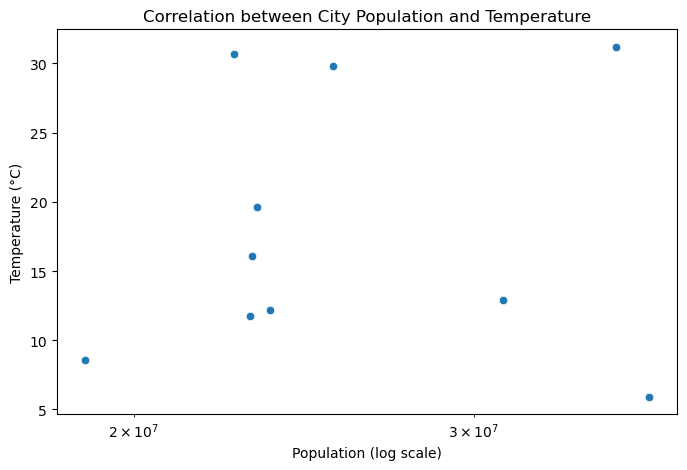

In [27]:
# Explore Correlation Between Population & Temperature

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.scatterplot(x=df["Population"], y=df["Temperature (°C)"])
plt.xscale("log")  # Log scale for better visualization
plt.xlabel("Population (log scale)")
plt.ylabel("Temperature (°C)")
plt.title("Correlation between City Population and Temperature")
plt.show()



In [28]:
# making more dynamic plot
import plotly.express as px

fig = px.scatter(
    df,
    x="Population",
    y="Temperature (°C)",
    log_x=True,  # Log scale for Population
    title="Correlation between City Population and Temperature",
    labels={"Population": "Population (log scale)", "Temperature (°C)": "Temperature (°C)"},
    hover_name="City",  # Optional: If you have a 'City' column to hover over
)

fig


## ***We can compute different types of correlation metrics. Examples are:***

**1. Pearson Correlation (Linear Relationship)**
Measures the strength and direction of a linear relationship between two variables.
Values range from -1 (perfect negative correlation) to +1 (perfect positive correlation), with 0 meaning no correlation.

**2. Spearman Correlation (Monotonic Relationship)**
Measures the rank-based correlation.
Works well even when the relationship is non-linear but monotonic (always increasing or always decreasing).

**3. Kendall’s Tau (Rank-Based Correlation)**
Another rank-based correlation, but more robust with small datasets.
Suitable when the data contains many ties (duplicate values).

**4. R-Squared Value (Goodness of Fit)**
Tells how much variation in Temperature is explained by Population.
Used in regression analysis.

**5. Mutual Information (Non-Linear Dependency)**
Measures how much knowing Population reduces uncertainty about Temperature.
Works for non-linear relationships.

In [29]:
import numpy as np
from scipy.stats import pearsonr, spearmanr, kendalltau
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import mutual_info_regression

# Sample DataFrame (Replace this with your actual dataset)
# Assuming df contains "Population" and "Temperature (°C)" columns
df = pd.DataFrame({
    "Population": [100000, 500000, 1000000, 2000000, 5000000, 10000000, 20000000, 50000000, 100000000],
    "Temperature (°C)": [15.2, 18.1, 20.5, 22.0, 24.5, 25.7, 26.3, 27.8, 29.1]
})

# Pearson Correlation
pearson_corr, _ = pearsonr(df["Population"], df["Temperature (°C)"])

# Spearman Correlation
spearman_corr, _ = spearmanr(df["Population"], df["Temperature (°C)"])

# Kendall's Tau Correlation
kendall_corr, _ = kendalltau(df["Population"], df["Temperature (°C)"])

# R-Squared Value (Goodness of Fit)
X = np.log(df["Population"]).values.reshape(-1, 1)  # Log transform Population
y = df["Temperature (°C)"]
model = LinearRegression().fit(X, y)
r_squared = model.score(X, y)

# Mutual Information Score
mi = mutual_info_regression(df[["Population"]], df["Temperature (°C)"])[0]

# Creating a DataFrame to display results
correlation_results = pd.DataFrame({
    "Correlation Method": ["Pearson", "Spearman", "Kendall's Tau", "R-Squared", "Mutual Information"],
    "Value": [pearson_corr, spearman_corr, kendall_corr, r_squared, mi]
})

correlation_results


,Correlation Method,Value
0,Pearson,0.717077
1,Spearman,1.000000
2,Kendall's Tau,1.000000
3,R-Squared,0.983607
4,Mutual Information,0.140873
